In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
%matplotlib inline

In [2]:
df = pd.read_csv('car_fuel_efficiency_2026_2.csv')

In [3]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [4]:
df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [5]:
df1 = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']].copy()


In [6]:
df1

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


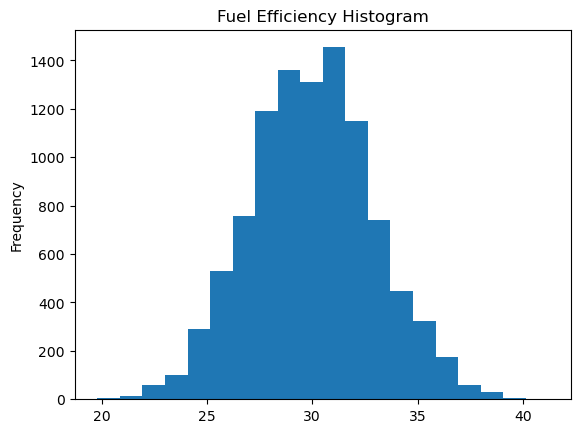

In [7]:

df['fuel_efficiency_mpg'].plot(kind='hist', bins=20, title='Fuel Efficiency Histogram')
plt.show()


In [8]:
df1.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [9]:
df1["horsepower"].median()

254.0

NameError: name 'df_val' is not defined

In [12]:


# --- 1. Clean Horsepower & Extract Target Variable ---
# Ensure horsepower is numeric across all splits
for split in [df_train, df_val]:
    split['horsepower'] = pd.to_numeric(split['horsepower'], errors='coerce')

# Extract targets (y)
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']


# --- 2. Evaluate Option 1: Mean Imputation ---
# Calculate the mean ONLY from the training set
train_hp_mean = df_train['horsepower'].mean()

X_train_mean = df_train[['horsepower']].fillna(train_hp_mean)
X_val_mean = df_val[['horsepower']].fillna(train_hp_mean)

# Fit model and predict
model_mean = LinearRegression().fit(X_train_mean, y_train)
preds_mean = model_mean.predict(X_val_mean)
rmse_mean = np.sqrt(np.mean((y_val - preds_mean) ** 2)) # Manual RMSE calculation


# --- 3. Evaluate Option 2: Zero Imputation ---
X_train_zero = df_train[['horsepower']].fillna(0)
X_val_zero = df_val[['horsepower']].fillna(0)

# Fit model and predict
model_zero = LinearRegression().fit(X_train_zero, y_train)
preds_zero = model_zero.predict(X_val_zero)
rmse_zero = np.sqrt(np.mean((y_val - preds_zero) ** 2))


# --- 4. Print the Comparison ---
print(f"Validation RMSE (Filled with Mean): {rmse_mean:.3f}")
print(f"Validation RMSE (Filled with 0):    {rmse_zero:.3f}")



NameError: name 'df_train' is not defined

In [ ]:

# --- 1. Prepare Data (Filling NAs with 0) ---
# Ensure columns are numeric
df_train['horsepower'] = pd.to_numeric(df_train['horsepower'], errors='coerce')
df_val['horsepower'] = pd.to_numeric(df_val['horsepower'], errors='coerce')

# Fill missing values with 0
X_train_zero = df_train[['horsepower']].fillna(0)
X_val_zero = df_val[['horsepower']].fillna(0)

y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']

# --- 2. Loop Through Regularization Values ---
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

print(f"{'r value':<10} | {'Validation RMSE':<15}")
print("-" * 30)

for r in r_values:
    # r=0 is standard linear regression. Ridge handles alpha=0 perfectly.
    model = Ridge(alpha=r) 
    model.fit(X_train_zero, y_train)
    
    # Predict and calculate manual RMSE
    preds = model.predict(X_val_zero)
    rmse = np.sqrt(np.mean((y_val - preds) ** 2))
    
    # Print rounded to 3 decimal places
    print(f"{r:<10} | {rmse:.3f}")


In [ ]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# 2. Loop through each seed to split, train, and evaluate
for seed in seeds:
    # Shuffle indices dynamically using the current seed
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    # Generate the train and validation datasets for this seed
    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    
    # Format and fill missing data with 0 (as instructed)
    df_train['horsepower'] = pd.to_numeric(df_train['horsepower'], errors='coerce').fillna(0)
    df_val['horsepower'] = pd.to_numeric(df_val['horsepower'], errors='coerce').fillna(0)
    
    # Split into features (X) and target (y)
    X_train = df_train[['horsepower']]
    y_train = df_train['fuel_efficiency_mpg']
    
    X_val = df_val[['horsepower']]
    y_val = df_val['fuel_efficiency_mpg']
    
    # Train the unregularized linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict and calculate manual RMSE
    preds = model.predict(X_val)
    rmse = np.sqrt(np.mean((y_val - preds) ** 2))
    
    # Save the score
    rmse_scores.append(rmse)

# 3. Calculate standard deviation and round to 3 decimal digits
std_value = np.std(rmse_scores)
final_std = round(std_value, 3)

# 4. View results
print(f"All RMSE scores: {rmse_scores}")
print(f"Standard Deviation: {final_std}")

In [ ]:
# --- 1. Split the Dataset (Seed 9) ---
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

# Initial split structure
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

# --- 2. Combine Train and Validation Datasets ---
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

# --- 3. Format, Clean, and Impute Missing Values with 0 ---
df_full_train['horsepower'] = pd.to_numeric(df_full_train['horsepower'], errors='coerce').fillna(0)
df_test['horsepower'] = pd.to_numeric(df_test['horsepower'], errors='coerce').fillna(0)

# Separate features (X) and target variable (y)
X_full_train = df_full_train[['horsepower']]
y_full_train = df_full_train['fuel_efficiency_mpg']

X_test = df_test[['horsepower']]
y_test = df_test['fuel_efficiency_mpg']

# --- 4. Train Regularized Linear Regression (r=0.001) ---
# Ridge regression takes alpha parameter which represents the regularizer r
model = Ridge(alpha=0.001)
model.fit(X_full_train, y_full_train)

# --- 5. Evaluate Performance on Test Dataset ---
test_preds = model.predict(X_test)
test_rmse = np.sqrt(np.mean((y_test - test_preds) ** 2))

# View final diagnostic score
print(f"Final Test Dataset RMSE: {test_rmse:.3f}")